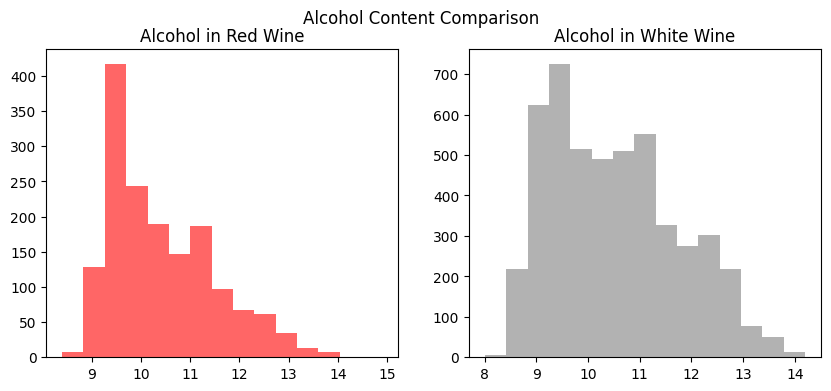

 Data loaded, scaled, and split! Total rows: 6497


In [ ]:
# ==========================================
# CELL 1: IMPORTS, DATA PREP & EXTRA VISUALIZATION
# ==========================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

# 1. Load data from URLs
# Define the exact web address (URL) where the raw Red Wine data is stored online.
url_red = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

# Define the exact web address (URL) where the raw White Wine data is stored online.
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

# pd.read_csv: Reads the data from the URL into a pandas DataFrame (table). 
# 'sep=;' tells pandas that the columns in this specific file are separated by semicolons, not commas.
df_red = pd.read_csv(url_red, sep=';')

# Reads the white wine data from its URL and separates the columns using semicolons.
df_white = pd.read_csv(url_white, sep=';')


# 2. Assign target variables (1 for Red, 0 for White) and combine
# Create a new column named 'wine_type' in the red wine table and fill every single row with the number 1.
df_red['wine_type'] = 1

# Create a new column named 'wine_type' in the white wine table and fill every single row with the number 0.
df_white['wine_type'] = 0

# pd.concat: Glues the red and white dataframes together vertically (one on top of the other). 
# 'ignore_index=True' completely resets the row numbers so they flow smoothly from 0 to the end.
df = pd.concat([df_red, df_white], ignore_index=True)

# dropna: Removes any rows that have missing or empty values (NaN). 
# 'inplace=True' means it applies this deletion directly to our existing 'df' variable without needing a new one.
df.dropna(inplace=True)


# 3. SPLIT & SCALE (Crucial for Neural Networks)
# df.drop: Removes the 'wine_type' column (axis=1 means column) and saves all the remaining chemical features as X.
X = df.drop('wine_type', axis=1)

# Selects ONLY the 'wine_type' column and saves it as y. This is the "answer key" our model must learn to predict.
y = df['wine_type']

# StandardScaler: Creates a mathematical tool that will equalize the scale of all numbers so big values don't overpower small ones.
scaler = StandardScaler()

# fit_transform: First calculates the math rules to scale the data (fit), and immediately applies those rules to X (transform).
X_scaled = scaler.fit_transform(X)

# train_test_split: Slices the data into two parts. 80% is saved for training (train), and 20% is locked away for testing (test_size=0.2). 
# 'random_state=42' ensures the data is shuffled the exact same way every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# 4. EXTRA VISUALIZATION 
# plt.subplots: Creates a blank canvas with 1 row and 2 columns (two side-by-side graphs). 'figsize' sets the width and height in inches.
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ax[0]: Targets the first (left) graph. .hist creates a histogram using the alcohol column of ONLY the red wines (where wine_type == 1). 
# 'bins=15' splits the data into 15 bars.
ax[0].hist(df[df['wine_type'] == 1].alcohol, bins=15, color='red', alpha=0.6)

# Adds a specific text title directly above the first (left) graph.
ax[0].set_title('Alcohol in Red Wine')

# ax[1]: Targets the second (right) graph. Plots the histogram for the alcohol content of white wines (where wine_type == 0).
ax[1].hist(df[df['wine_type'] == 0].alcohol, bins=15, color='gray', alpha=0.6)

# Adds a specific text title directly above the second (right) graph.
ax[1].set_title('Alcohol in White Wine')

# plt.suptitle: Adds a "Super Title" that hovers centered over the entire figure (covering both graphs).
plt.suptitle('Alcohol Content Comparison')

# plt.show: Takes all the drawing instructions above and actually renders/displays the final graphic on the screen.
plt.show()

print(f" Data loaded, scaled, and split! Total rows: {len(df)}")

In [ ]:
# ==========================================
# CELL 2: EXPERIMENT LOOP & LOGBOOK GENERATION
# ==========================================

# 1. Define a list of dictionaries. Each dictionary is a unique experiment blueprint.
experiments = [
    {'id': 1, 'nodes': [8], 'epochs': 20, 'lr': 0.001, 'note': 'Baseline (1 Hidden Layer)'},
    {'id': 2, 'nodes': [16, 8], 'epochs': 20, 'lr': 0.001, 'note': 'Deeper Network (2 Layers)'},
    {'id': 3, 'nodes': [32, 16], 'epochs': 20, 'lr': 0.001, 'note': 'Wider & Deeper'},
    {'id': 4, 'nodes': [32, 16], 'epochs': 50, 'lr': 0.001, 'note': 'More Epochs (50)'},
    {'id': 5, 'nodes': [32, 16], 'epochs': 20, 'lr': 0.01, 'note': 'High Learning Rate (Fast but risky)'},
    {'id': 6, 'nodes': [32, 16], 'epochs': 20, 'lr': 0.0001, 'note': 'Low Learning Rate (Slow and steady)'},
    {'id': 7, 'nodes': [64, 32, 16], 'epochs': 20, 'lr': 0.001, 'note': 'Too Deep (Overfitting Risk)'},
    {'id': 8, 'nodes': [16, 8], 'epochs': 10, 'lr': 0.001, 'note': 'Too Few Epochs (Underfitting Risk)'},
    {'id': 9, 'nodes': [32, 16], 'epochs': 20, 'lr': 0.005, 'note': 'Balanced Learning Rate'},
    {'id': 10, 'nodes': [32, 16, 8], 'epochs': 50, 'lr': 0.001, 'note': 'Complex pattern testing'}
]

results = []
print("Starting automated loop optimization...\n")

# 2. The FOR LOOP that dynamically builds and tests each model
# Starts a loop that goes through every single experiment blueprint (dictionary) inside our 'experiments' list one by one.
for exp in experiments:
    
    # Creates a fresh, empty Neural Network where data flows straight from left to right (Sequential).
    model = Sequential()
    
    # enumerate: Starts a sub-loop for the layers. It gives us the layer index number (i) and the number of nodes requested (node_count).
    #This loop goes through every hidden layer defined for the current experiment. It reads how many nodes each hidden layer should have and then creates that layer in the neural network
    for i, node_count in enumerate(exp['nodes']):
        
        # Checks if this is the very first hidden layer in the network (index 0).
        if i == 0:
            # Dense: A fully connected layer. 'activation=relu' uses a math filter that blocks negative numbers. 
            # 'input_dim=X_train.shape[1]' tells this first layer exactly how many chemical feature columns are entering the network.
            model.add(Dense(node_count, activation='relu', input_dim=X_train.shape[1]))
            
        # If it is NOT the first layer (it's the 2nd, 3rd, etc.).
        else:
            # Adds another Dense layer. We don't need 'input_dim' here because Keras automatically calculates it from the previous layer.
            model.add(Dense(node_count, activation='relu'))
            
    # Adds the final output layer. It has only 1 node because we only need one Yes/No answer. 
    # 'activation=sigmoid' mathematically squashes the final prediction into a probability strictly between 0.0 and 1.0.
    model.add(Dense(1, activation='sigmoid')) 
    
    # model.compile: Prepares the network for training. 'loss=binary_crossentropy' is the standard math formula for measuring errors in 1/0 classification tasks. 
    # 'optimizer=Adam' is the algorithm that adjusts the weights, using the specific learning rate (lr) from our blueprint.
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=exp['lr']), metrics=['accuracy'])
    
    # model.fit: Actually trains the model. 'epochs' is how many times it studies the data. 
    # 'batch_size=32' means it updates its weights after looking at 32 rows at a time. 'verbose=0' hides the loading bars to keep the screen clean.
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=32, verbose=0)
    
    # model.evaluate: Tests the fully trained model against the unseen 20% test data. It returns the final calculated loss and accuracy scores.
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Save results to the logbook list
    results.append({
        'Experiment': f"Exp {exp['id']}",
        'Architecture': str(exp['nodes']),
        'Epochs': exp['epochs'],
        'Learning Rate': exp['lr'],
        'Accuracy': round(accuracy, 4),
        'Note': exp['note']
    })
    print(f"✅ Exp {exp['id']} Completed -> Accuracy: {accuracy:.4f}")

# 3. Export Logbook to Excel and display it
df_logboek = pd.DataFrame(results)
df_logboek.to_excel("ML_TensorFlow_Loop_Logboek.xlsx", index=False)
display(df_logboek)

Starting automated loop optimization...

✅ Exp 1 Completed -> Accuracy: 0.9923
✅ Exp 2 Completed -> Accuracy: 0.9946
✅ Exp 3 Completed -> Accuracy: 0.9946
✅ Exp 4 Completed -> Accuracy: 0.9962
✅ Exp 5 Completed -> Accuracy: 0.9954
✅ Exp 6 Completed -> Accuracy: 0.9908
✅ Exp 7 Completed -> Accuracy: 0.9946
✅ Exp 8 Completed -> Accuracy: 0.9923
✅ Exp 9 Completed -> Accuracy: 0.9954
✅ Exp 10 Completed -> Accuracy: 0.9969


,Experiment,Architecture,Epochs,Learning Rate,Accuracy,Note
0,Exp 1,[8],20,0.0010,0.9923,Baseline (1 Hidden Layer)
1,Exp 2,"[16, 8]",20,0.0010,0.9946,Deeper Network (2 Layers)
2,Exp 3,"[32, 16]",20,0.0010,0.9946,Wider & Deeper
3,Exp 4,"[32, 16]",50,0.0010,0.9962,More Epochs (50)
4,Exp 5,"[32, 16]",20,0.0100,0.9954,High Learning Rate (Fast but risky)
5,Exp 6,"[32, 16]",20,0.0001,0.9908,Low Learning Rate (Slow and steady)
6,Exp 7,"[64, 32, 16]",20,0.0010,0.9946,Too Deep (Overfitting Risk)
7,Exp 8,"[16, 8]",10,0.0010,0.9923,Too Few Epochs (Underfitting Risk)
8,Exp 9,"[32, 16]",20,0.0050,0.9954,Balanced Learning Rate
9,Exp 10,"[32, 16, 8]",50,0.0010,0.9969,Complex pattern testing


--- TRAINING FINAL CHAMPION MODEL ---


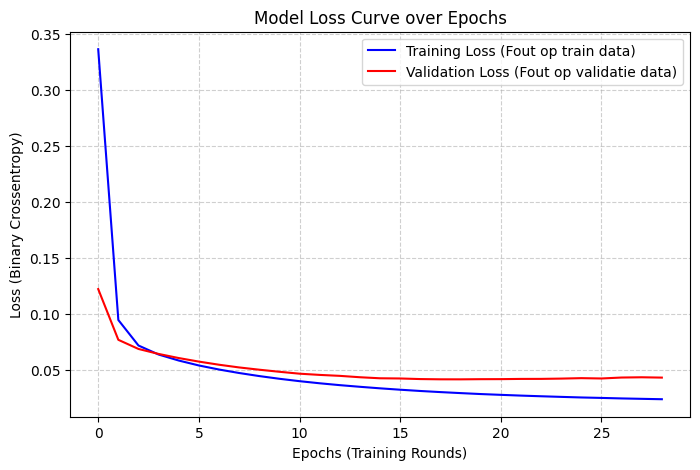

In [ ]:
# ==========================================
# CELL 3: MANUAL OPTIMIZATION (FINAL MODEL) & LOSS PLOT
# ==========================================

print("--- TRAINING FINAL CHAMPION MODEL ---")

# 1. Building the final model manually  using the best findings from our loop
# Creates our best model and immediately defines all of its layers inside the brackets.
final_model = Sequential([
    # 1st Hidden Layer: 32 nodes. 'kernel_regularizer=l2(0.001)' applies a mathematical penalty to overly large weights. 
    # This prevents the model from memorizing the training data perfectly (overfitting).
    Dense(32, activation='relu', kernel_regularizer=l2(0.001), input_dim=X_train.shape[1]),
    
    # 2nd Hidden Layer: 16 nodes, also using the 'relu' activation and the same 'l2' penalty for stability.
    Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
    
    # Final Output Layer: 1 node with the 'sigmoid' function to output a clean 0 to 1 probability (White vs Red).
    Dense(1, activation='sigmoid')
])

# Prepares our best model. We explicitly set the Adam optimizer to take small, careful learning steps (learning_rate=0.001).
# model.compile: Configures the neural network for training. 
# 'optimizer=Adam' updates the model's weights, 'learning_rate=0.001' controls how large each update step is, 
# 'loss=binary_crossentropy' measures prediction errors for binary (0/1) classification, 
# and 'metrics=["accuracy"]' tracks the percentage of correct predictions during training.
final_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# EarlyStopping: Creates a monitor that constantly checks the validation error ('val_loss'). 
# 'patience=10' means if the error doesn't improve for 10 rounds, it hits the brakes. 'restore_best_weights=True' forces it to rewind to its best state.
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# final_model.fit: Trains the champion model. 'validation_split=0.2' temporarily holds back another 20% of the training data just for the EarlyStopper to monitor. 
# 'callbacks=[early_stop]' attaches the brake system. 'history =' saves all the error scores round-by-round so we can plot them on a graph later.
history = final_model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stop], verbose=0)

# 4. PLOTTING THE LOSS PLOT (Requirement Met)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (Fout op train data)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (Fout op validatie data)', color='red')
plt.title('Model Loss Curve over Epochs')
plt.xlabel('Epochs (Training Rounds)')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


--- FINAL CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

White Wine (0)       0.99      1.00      1.00       959
  Red Wine (1)       1.00      0.98      0.99       341

      accuracy                           1.00      1300
     macro avg       1.00      0.99      0.99      1300
  weighted avg       1.00      1.00      1.00      1300



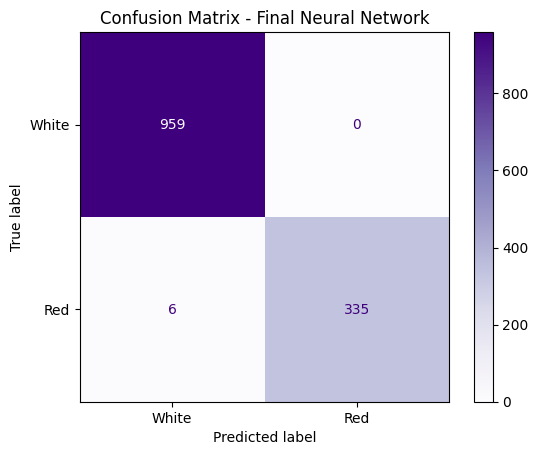

In [9]:
# ==========================================
# CELL 4: FINAL EVALUATION & CONFUSION MATRIX
# ==========================================

# 1. Make predictions
y_pred_probs = final_model.predict(X_test, verbose=0)
# Convert probabilities (0.0 to 1.0) into hard labels (0 or 1)
y_pred_final = (y_pred_probs >= 0.5).astype(int)

# 2. Classification Report
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_final, target_names=['White Wine (0)', 'Red Wine (1)']))

# 3. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='Purples', display_labels=['White', 'Red'])
plt.title("Confusion Matrix - Final Neural Network")
plt.show()